In [42]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [3]:
T = 2
d = 3

br = np.array([
    [11, 0, 0],
    [0, 10, 0],
    [0, 0, 5],
])
dr = np.array([1, 2, 1])
mr = np.array([
    [0, 2, 1],
    [0, 0, 2],
    [3, 1, 0],
])
sr = np.array([0.1, 0.2, 0.5])

/Users/ochsneto/Documents/BDMM/BDMM-Flow-Supplementary/.venv/lib/python3.9/site-packages/scipy/integrate/_ivp/rk.py:505: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  super().__init__(fun, t0, y0, t_bound, max_step, rtol, atol,


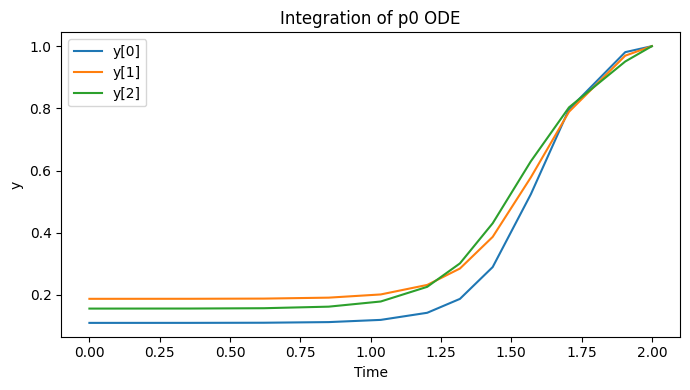

In [4]:
from scipy.integrate import solve_ivp

def compute_p0_derivatives(t, y):
    d = len(y)
    dydt = np.zeros_like(y)
    for i in range(d):
        dydt[i] = (
            br[i,i] + dr[i] + sr[i] - br[i,i] * y[i]
        ) * y[i]
        
        # Cross-birth and migration contributions
        for j in range(d):
            if i == j:
                continue

            cross_birth = br[i,j] * (y[i] - y[i] * y[j])
            migration = mr[i,j] * (y[i] - y[j])
            dydt[i] += cross_birth + migration

        dydt[i] -= dr[i]

    return dydt

y0 = np.ones(d)

p0_sol = solve_ivp(
    fun=lambda t, y: compute_p0_derivatives(t, y),
    t_span=(T, 0),
    y0=y0,
    dense_output=True,
    method="DOP853",
    rtol=1e-14
)

plt.figure(figsize=(7,4))
for i in range(d):
    plt.plot(p0_sol.t, p0_sol.y[i], label=f'y[{i}]')
plt.xlabel('Time')
plt.ylabel('y')
plt.title('Integration of p0 ODE')
plt.legend()
plt.tight_layout()
plt.show()

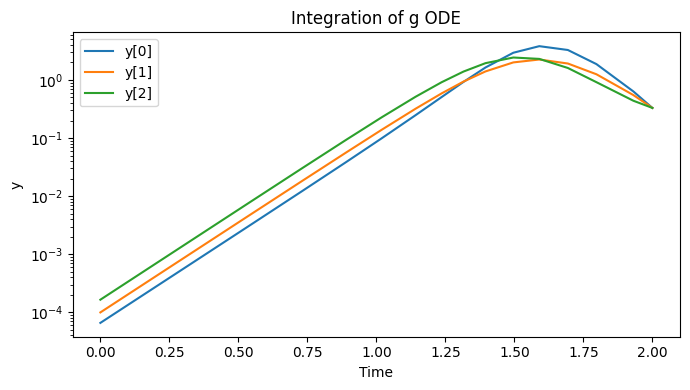

In [5]:
def get_g_system(t):
    A = np.zeros((d, d))
    p0 = p0_sol.sol(t)

    for i in range(d):
        A[i, i] += dr[i] + sr[i] + br[i, i] - 2 * br[i, i] * p0[i]

        for j in range(d):
            if i == j:
                continue

            A[i, i] += mr[i, j] + br[i, j] - br[i, j]*p0[j]
            A[i, j] -= mr[i, j] - br[i, j]*p0[i]

    return A

def compute_g_derivatives(t, y):
    A = get_g_system(t)
    return A @ y

y0 = np.array([0.33, 0.33, 0.33])

g_sol = solve_ivp(
    fun=lambda t, y: compute_g_derivatives(t, y),
    t_span=(T, 0),
    y0=y0,
    dense_output=True,
    method="DOP853",
    rtol=1e-14
)

plt.figure(figsize=(7,4))
for i in range(d):
    plt.plot(g_sol.t, g_sol.y[i], label=f'y[{i}]')
    plt.yscale("log")
plt.xlabel('Time')
plt.ylabel('y')
plt.title('Integration of g ODE')
plt.legend()
plt.tight_layout()
plt.show()

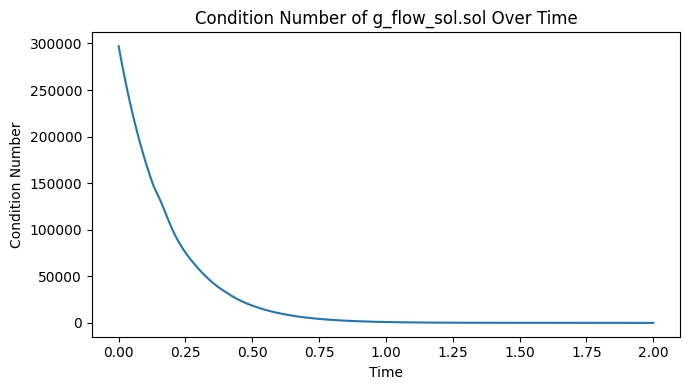

In [6]:
def compute_g_flow_derivatives(t, y):
    A = get_g_system(t)
    return (A @ y.reshape(d, d)).flatten()

y0 = np.identity(d)

g_flow_sol = solve_ivp(
    fun=lambda t, y: compute_g_flow_derivatives(t, y),
    t_span=(T, 0),
    y0=y0.flatten(),
    dense_output=True,
    method="DOP853",
    rtol=1e-14
)

times = np.linspace(T, 0, 200)
cond_numbers = []

for t in times:
    h_flow_mat = g_flow_sol.sol(t).reshape(d, d)
    cond = np.linalg.cond(h_flow_mat)
    cond_numbers.append(cond)

plt.figure(figsize=(7,4))
plt.plot(times, cond_numbers)
plt.xlabel('Time')
plt.ylabel('Condition Number')
plt.title('Condition Number of g_flow_sol.sol Over Time')
plt.tight_layout()
plt.show()

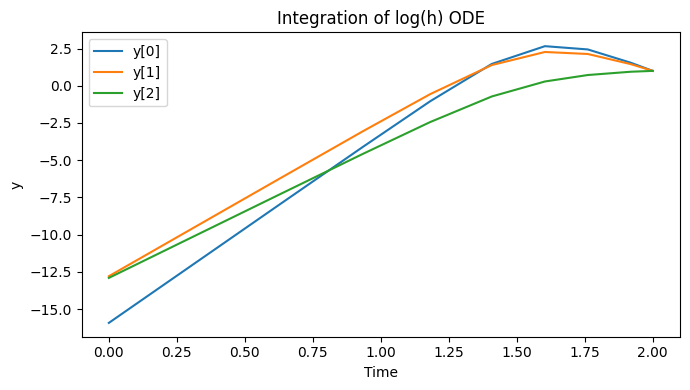

In [7]:
def compute_h_derivatives(t, y):
    d = len(y)
    p0 = p0_sol.sol(t)
    dydt = np.zeros_like(y)
    for i in range(d):
        dydt[i] += dr[i] + sr[i]
        dydt[i] -= br[i, i] * p0[i]

        for j in range(d):
            dydt[i] += br[i, j] + mr[i, j]
            dydt[i] -= br[i, j] * p0[j]

    return dydt

y0 = np.ones(d)

h_sol = solve_ivp(
    fun=lambda t, y: compute_h_derivatives(t, y),
    t_span=(T, 0),
    y0=y0,
    dense_output=True,
    method="DOP853",
    rtol=1e-14
)

plt.figure(figsize=(7,4))
for i in range(d):
    plt.plot(h_sol.t, h_sol.y[i], label=f'y[{i}]')
plt.xlabel('Time')
plt.ylabel('y')
plt.title('Integration of log(h) ODE')
plt.legend()
plt.tight_layout()
plt.show()

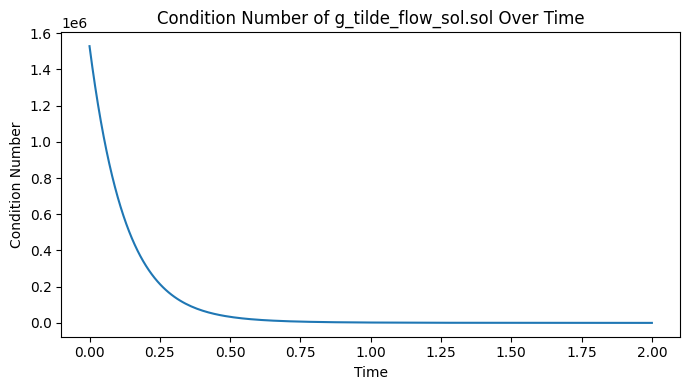

In [8]:
def get_g_tilde_system(t):
    A = np.zeros((d, d))
    p0 = p0_sol.sol(t)
    h = h_sol.sol(t)

    for i in range(d):
        for j in range(d):
            if i == j:
                continue

            h_ratio = np.exp(h[j] - h[i])

            A[i, j] -= h_ratio * (mr[i, j] - br[i, j]*p0[i])

    return A

def compute_g_tilde_flow_derivatives(t, y):
    A = get_g_tilde_system(t)
    return (A @ y.reshape(d, d)).flatten()

y0 = np.identity(d)

g_tilde_flow_sol = solve_ivp(
    fun=lambda t, y: compute_g_tilde_flow_derivatives(t, y),
    t_span=(T, 0),
    y0=y0.flatten(),
    dense_output=True,
    method="DOP853",
    rtol=1e-14
)

times = np.linspace(T, 0, 200)
cond_numbers = []

for t in times:
    h_flow_mat = g_tilde_flow_sol.sol(t).reshape(d, d)
    cond = np.linalg.cond(h_flow_mat)
    cond_numbers.append(cond)

plt.figure(figsize=(7,4))
plt.plot(times, cond_numbers)
plt.xlabel('Time')
plt.ylabel('Condition Number')
plt.title('Condition Number of g_tilde_flow_sol.sol Over Time')
plt.tight_layout()
plt.show()

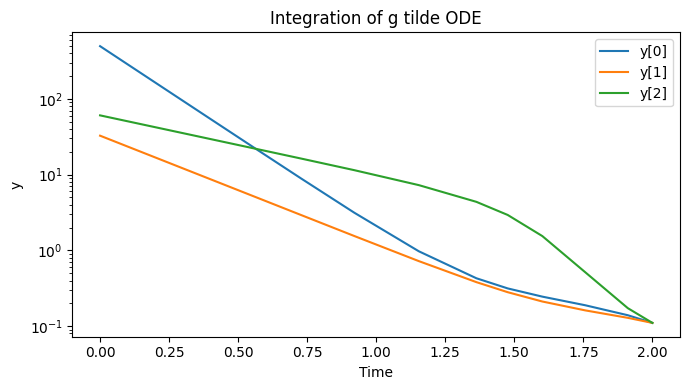

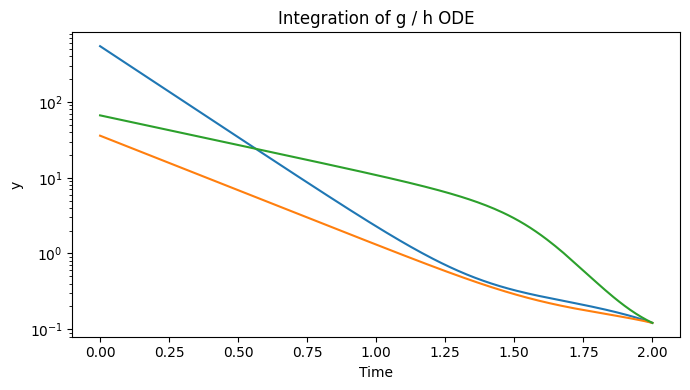

In [9]:
def compute_g_tilde_derivatives(t, y):
    A = get_g_tilde_system(t)
    return A @ y

y0 = np.array([0.3, 0.3, 0.3]) / np.exp(1.0)

g_tilde_sol = solve_ivp(
    fun=lambda t, y: compute_g_tilde_derivatives(t, y),
    t_span=(T, 0),
    y0=y0,
    dense_output=True,
    method="DOP853",
    rtol=1e-14
)

plt.figure(figsize=(7,4))
for i in range(d):
    plt.plot(g_tilde_sol.t, g_tilde_sol.y[i], label=f'y[{i}]')
    plt.yscale("log")
plt.xlabel('Time')
plt.ylabel('y')
plt.title('Integration of g tilde ODE')
plt.legend()
plt.tight_layout()
plt.show()

times = np.linspace(T, 0, 200)
values = []

for t in times:
    values.append(g_sol.sol(t) / np.exp(h_sol.sol(t)))

plt.figure(figsize=(7,4))
plt.plot(times, values)
plt.xlabel('Time')
plt.ylabel('y')
plt.title('Integration of g / h ODE')
plt.yscale("log")
plt.tight_layout()
plt.show()

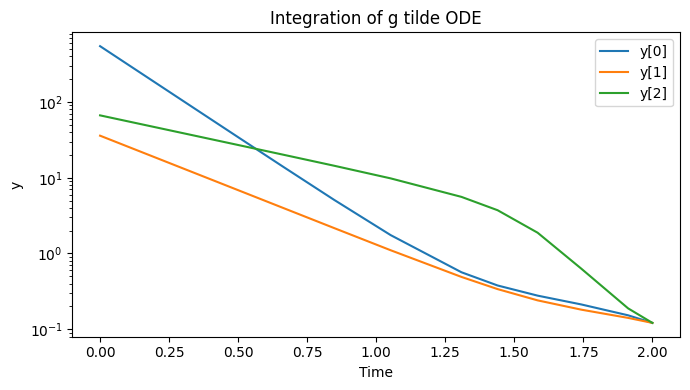

In [10]:
def compute_g_tilde_derivatives(t, y):
    A = get_g_tilde_system(t)
    return A @ y

y0 = np.array([0.33, 0.33, 0.33]) / np.exp(1.0)

g_tilde_sol = solve_ivp(
    fun=lambda t, y: compute_g_tilde_derivatives(t, y),
    t_span=(T, 0),
    y0=y0,
    dense_output=True,
    method="DOP853",
    rtol=1e-14
)

plt.figure(figsize=(7,4))
for i in range(d):
    plt.plot(g_tilde_sol.t, g_tilde_sol.y[i], label=f'y[{i}]')
    plt.yscale("log")
plt.xlabel('Time')
plt.ylabel('y')
plt.title('Integration of g tilde ODE')
plt.legend()
plt.tight_layout()
plt.show()

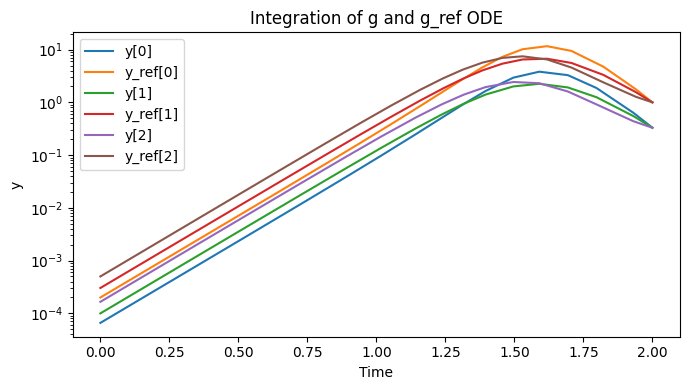

In [11]:
g_ref_sol = solve_ivp(
    fun=lambda t, y: compute_g_derivatives(t, y),
    t_span=(T, 0),
    y0=np.array([1, 1, 1]),
    dense_output=True,
    method="DOP853",
    rtol=1e-14
)

plt.figure(figsize=(7,4))
for i in range(d):
    plt.plot(g_sol.t, g_sol.y[i], label=f'y[{i}]')
    plt.plot(g_ref_sol.t, g_ref_sol.y[i], label=f'y_ref[{i}]')
    plt.yscale("log")
plt.xlabel('Time')
plt.ylabel('y')
plt.title('Integration of g and g_ref ODE')
plt.legend()
plt.tight_layout()
plt.show()

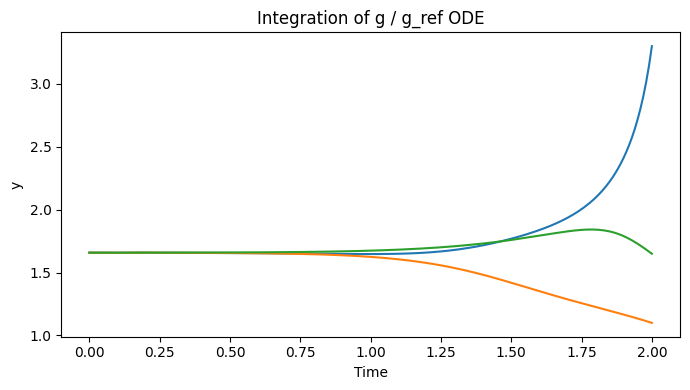

In [12]:
g_ref_sol = solve_ivp(
    fun=lambda t, y: compute_g_derivatives(t, y),
    t_span=(T, 0),
    y0=np.array([0.1, 0.3, 0.2]),
    dense_output=True,
    method="DOP853",
    rtol=1e-14
)

times = np.linspace(T, 0, 200)
values = []

for t in times:
    values.append(g_sol.sol(t) / g_ref_sol.sol(t))

plt.figure(figsize=(7,4))
plt.plot(times, values)
plt.xlabel('Time')
plt.ylabel('y')
plt.title('Integration of g / g_ref ODE')
plt.tight_layout()
plt.show()

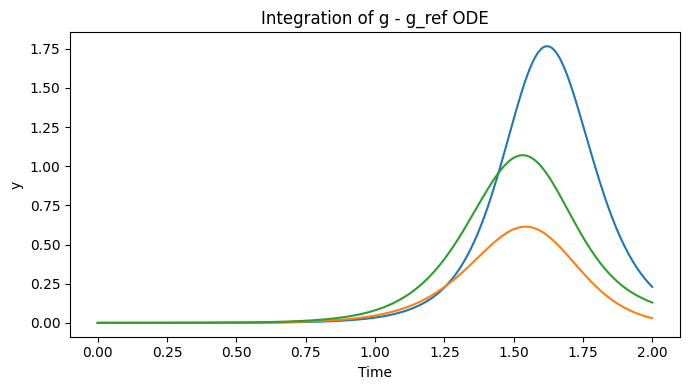

In [13]:
g_ref_sol = solve_ivp(
    fun=lambda t, y: compute_g_derivatives(t, y),
    t_span=(T, 0),
    y0=np.array([0.1, 0.3, 0.2]),
    dense_output=True,
    method="DOP853",
    rtol=1e-14
)

times = np.linspace(T, 0, 200)
values = []

for t in times:
    values.append(g_sol.sol(t) - g_ref_sol.sol(t))

plt.figure(figsize=(7,4))
plt.plot(times, values)
plt.xlabel('Time')
plt.ylabel('y')
plt.title('Integration of g - g_ref ODE')
plt.tight_layout()
plt.show()

In [14]:
A = np.array([
    [0, -10000000],
    [-10, 0],
])



X = np.expm1(A*T)
np.linalg.cond(X)

np.float64(1.0000000020611537)

/Users/ochsneto/Documents/BDMM/BDMM-Flow-Supplementary/.venv/lib/python3.9/site-packages/scipy/integrate/_ivp/rk.py:505: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  super().__init__(fun, t0, y0, t_bound, max_step, rtol, atol,


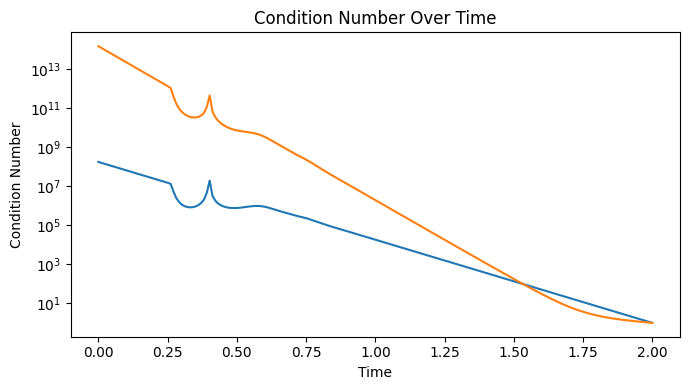

In [62]:
d = 3
T = 2

def compute_derivatives(t, y):
    A = np.array([
        [10, -1, -1],
        [-1, 3, -1],
        [-1, -1, 1],
    ])
    return (A @ y.reshape(d, d)).flatten()

sol = solve_ivp(
    fun=lambda t, y: compute_derivatives(t, y),
    t_span=(T, 0),
    y0=np.eye(3).flatten(),
    dense_output=True,
    method="DOP853",
    rtol=1e-14
)

times = np.linspace(T, 0, 200)
cond_numbers_x = []
cond_numbers_y = []

for t in times:
    X = sol.sol(t).reshape(d, d)
    Y = sp.linalg.expm(
        (T-t)*np.array([
            [10, 0, 0],
            [0, 3, 0],
            [0, 0, 1],
        ])
    ) @ X
    cond_numbers_x.append(np.linalg.cond(X))
    cond_numbers_y.append(np.linalg.cond(Y))

plt.figure(figsize=(7,4))
plt.plot(times, cond_numbers_x)
plt.plot(times, cond_numbers_y)
plt.xlabel('Time')
plt.ylabel('Condition Number')
plt.title('Condition Number Over Time')
plt.yscale("log")
plt.tight_layout()
plt.show()

In [46]:
Y

array([[0.00444957, 0.00842041, 0.00582879],
       [0.00842041, 0.01610715, 0.01101204],
       [0.00582879, 0.01101204, 0.00768673]])

In [ ]:
A = np.array([
    [7.5, -4],
    [-3, -7.5],
])
M = np.expm1(A*4)
M, np.linalg.cond(M)

(array([[ 1.06864746e+13, -9.99999887e-01],
        [-9.99993856e-01, -1.00000000e+00]]),
 np.float64(10686474581523.463))

In [ ]:
P = np.array([[20, 0], [0, 20]])
B = A @ P
B

M = P @ np.expm1(A*4)
M, np.linalg.cond(M)

(array([[ 1.10812448e+36, -1.99999977e+01],
        [-1.99998771e+01,  9.70330389e+09]]),
 np.float64(1.1420073921695371e+26))

In [ ]:
P = np.array([[1/20, 0], [0, 1/5]])
M = np.expm1(A @ *4)
A, M, np.linalg.cond(M)

(array([[20, -4],
        [-3,  5]]),
 array([[ 5.54062238e+34, -9.99999887e-01],
        [-9.99993856e-01,  4.85165194e+08]]),
 np.float64(1.142007392169537e+26))

In [ ]:
A = np.array([
    [20, -4],
    [-3, 5],
])
M = np.expm1(A*4)
A, M, np.linalg.cond(M)